In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [3]:
df = pd.read_csv("/workspaces/-Financial_Fraud_Analytics_Platform/data/processed/cleaned_creditcard.csv")

print("Dataset Loaded Successfully!")
print("Shape:", df.shape)

df.head()

Dataset Loaded Successfully!
Shape: (50119, 12)


,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,T1,4174,1292.76,ATM Withdrawal,16.0,Tablet,San Francisco,0,119,13,Debit Card,0
1,T2,4507,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0
2,T3,1860,2395.02,ATM Withdrawal,NaN,Mobile,NaN,3,115,9,NaN,0
3,T4,2294,100.10,Bill Payment,15.0,Desktop,Chicago,4,3,4,UPI,0
4,T5,2130,1490.50,POS Payment,19.0,Mobile,San Francisco,2,57,7,Credit Card,0


In [4]:
print("Dataset Information")
print("-" * 50)

df.info()

Dataset Information
--------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 50119 entries, 0 to 50118
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Transaction_ID                    50119 non-null  str    
 1   User_ID                           50119 non-null  int64  
 2   Transaction_Amount                47643 non-null  float64
 3   Transaction_Type                  50119 non-null  str    
 4   Time_of_Transaction               47614 non-null  float64
 5   Device_Used                       47682 non-null  str    
 6   Location                          47619 non-null  str    
 7   Previous_Fraudulent_Transactions  50119 non-null  int64  
 8   Account_Age                       50119 non-null  int64  
 9   Number_of_Transactions_Last_24H   50119 non-null  int64  
 10  Payment_Method                    47691 non-null  str    
 11  Fraudul

In [5]:
df.describe()

,User_ID,Transaction_Amount,Time_of_Transaction,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Fraudulent
count,50119.000000,47643.000000,47614.000000,50119.000000,50119.000000,50119.000000,50119.000000
mean,3004.733195,2999.104599,11.488575,1.996448,60.029071,7.495640,0.049223
std,1152.620471,5061.206189,6.921244,1.415492,34.392569,4.019806,0.216335
min,1000.000000,5.030000,0.000000,0.000000,1.000000,1.000000,0.000000
25%,2007.000000,1269.830000,5.000000,1.000000,30.000000,4.000000,0.000000
50%,2997.000000,2523.580000,12.000000,2.000000,60.000000,7.000000,0.000000
75%,4005.000000,3785.090000,17.000000,3.000000,90.000000,11.000000,0.000000
max,4999.000000,49997.800000,23.000000,4.000000,119.000000,14.000000,1.000000


In [6]:
print("Missing Values")

df.isnull().sum()

Missing Values


Transaction_ID                         0
User_ID                                0
Transaction_Amount                  2476
Transaction_Type                       0
Time_of_Transaction                 2505
Device_Used                         2437
Location                            2500
Previous_Fraudulent_Transactions       0
Account_Age                            0
Number_of_Transactions_Last_24H        0
Payment_Method                      2428
Fraudulent                             0
dtype: int64

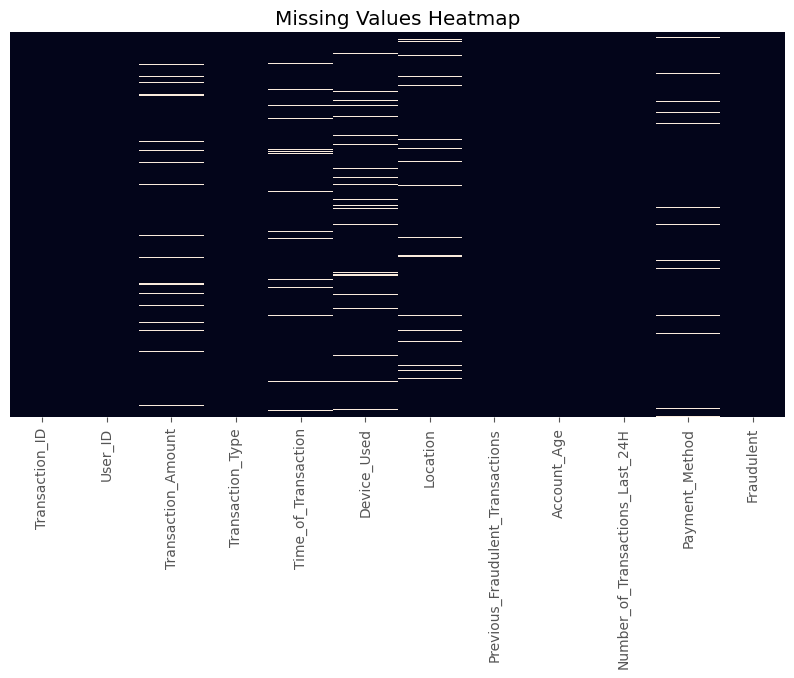

In [7]:
plt.figure(figsize=(10,5))

sns.heatmap(df.isnull(),
            cbar=False,
            yticklabels=False)

plt.title("Missing Values Heatmap")

plt.show()


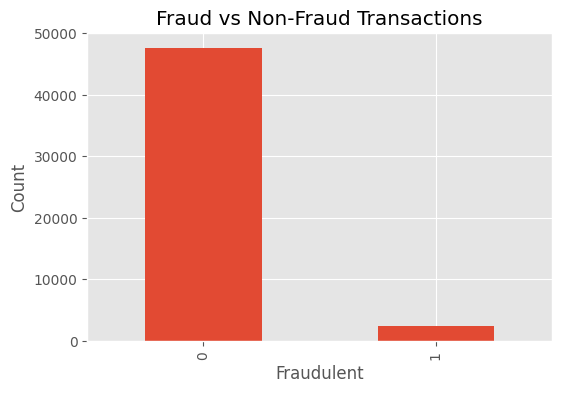

In [8]:
plt.figure(figsize=(6,4))

df["Fraudulent"].value_counts().plot(
    kind="bar"
)

plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("Fraudulent")
plt.ylabel("Count")

plt.show()

In [9]:
fraud_rate = (df["Fraudulent"].sum() / len(df)) * 100

print(f"Fraud Percentage: {fraud_rate:.2f}%")

Fraud Percentage: 4.92%


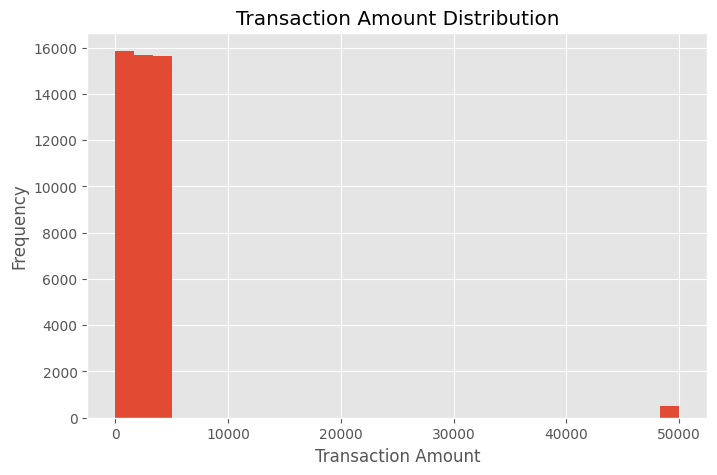

In [10]:
plt.figure(figsize=(8,5))

df["Transaction_Amount"].hist(
    bins=30
)

plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

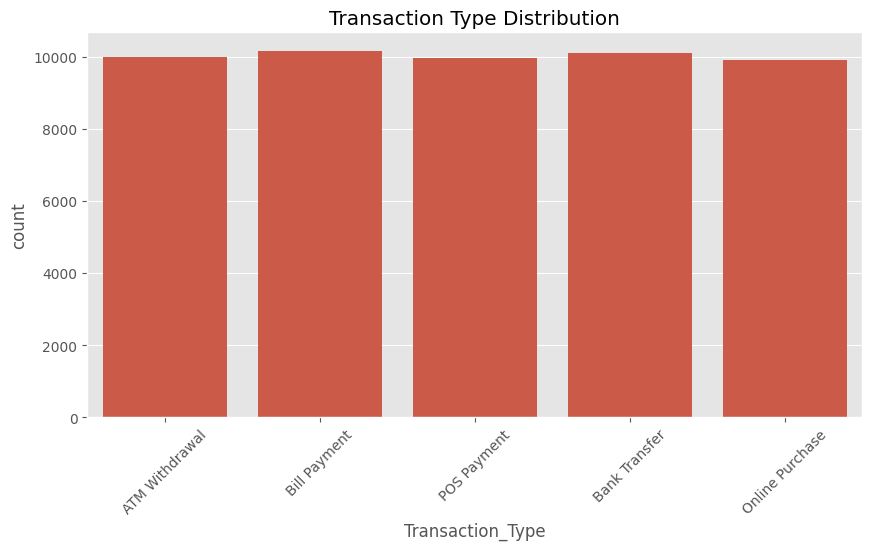

In [11]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="Transaction_Type"
)

plt.xticks(rotation=45)

plt.title("Transaction Type Distribution")

plt.show()

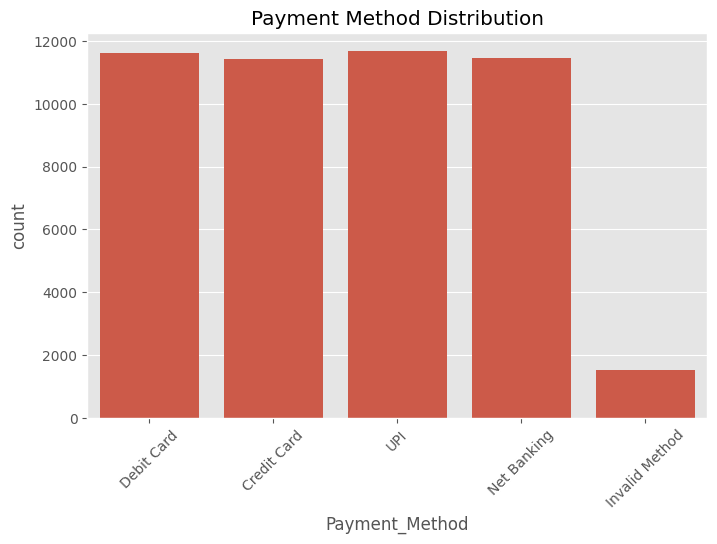

In [12]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Payment_Method"
)

plt.xticks(rotation=45)

plt.title("Payment Method Distribution")

plt.show()

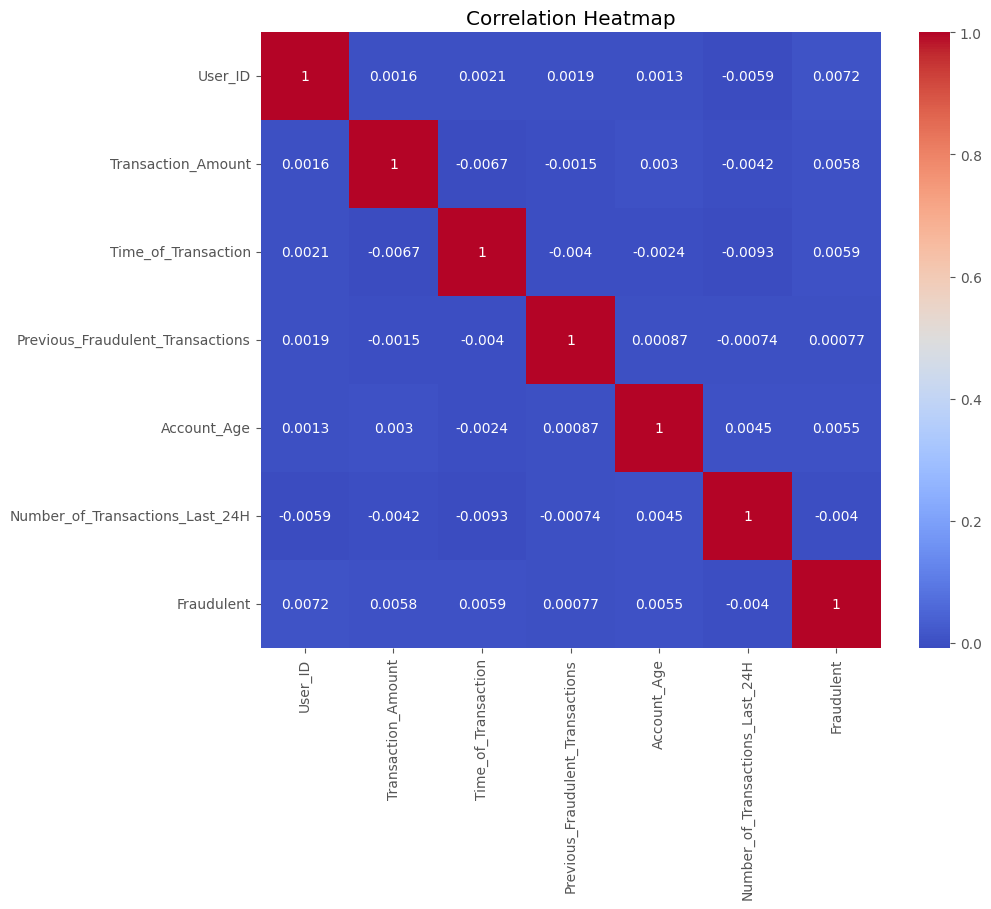

In [13]:
numeric_df = df.select_dtypes(
    include=["int64", "float64"]
)

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

# Key Findings

- Dataset contains over 50,000 financial transactions.
- Missing values exist in multiple transaction-related features.
- Fraudulent transactions form a smaller portion of total transactions.
- Transaction amounts show variation across records.
- Different payment methods and transaction types are used by customers.
- Correlation analysis reveals relationships among numerical features.